# Customer Retention Analysis

The **objective** of this notebook is to investigate customer purchasing
behavior from a retention perspective.

The analysis will examine:

- repeat versus one-time customers
- customer purchase frequency
- time between purchases
- customer inactivity
- relationships between RFM characteristics and retention behavior

The SQL results are compared with the Python aggregation to validate
the customer-level retention metrics.

This analysis will be used to develop a defensible customer retention /
churn target for the subsequent machine learning stage.

RFM "At Risk" segmentation is treated as a behavioral segmentation,
not as the final churn label.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path.cwd().parent
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

sales_file = PROCESSED_DIR / "retail_sales_cleaned.csv"
rfm_file = PROCESSED_DIR / "customer_rfm.csv"

sales_df = pd.read_csv(sales_file, parse_dates=["InvoiceDate"])
rfm = pd.read_csv(rfm_file)

print("Sales data:", sales_df.shape)
print("RFM data:", rfm.shape)

C:\Users\tanya\AppData\Local\Temp\ipykernel_8772\96339822.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_df = pd.read_csv(sales_file, parse_dates=["InvoiceDate"])


Sales data: (524878, 10)
RFM data: (4338, 9)


In [8]:
import duckdb

con = duckdb.connect()

print("DuckDB connection established.")

DuckDB connection established.


### 1. Customer Order History

The raw dataset contains individual product-line transactions.
For retention analysis, an invoice represents a customer order.
Therefore, the analysis will work at the customer-order level when
measuring repeat purchasing and purchase intervals.


In [2]:
# Create one record per customer order
customer_orders = (
    sales_df[["CustomerID", "InvoiceNo", "InvoiceDate"]]
    .dropna(subset=["CustomerID"])
    .drop_duplicates(subset=["CustomerID", "InvoiceNo"])
    .sort_values(["CustomerID", "InvoiceDate"])
    .reset_index(drop=True)
)
print("Customer-order dataset:", customer_orders.shape)
customer_orders.head()

Customer-order dataset: (18533, 3)


,CustomerID,InvoiceNo,InvoiceDate
0,12346.0,541431,2011-01-18 10:01:00
1,12347.0,537626,2010-12-07 14:57:00
2,12347.0,542237,2011-01-26 14:30:00
3,12347.0,549222,2011-04-07 10:43:00
4,12347.0,556201,2011-06-09 13:01:00


In [20]:
# Customer order counts using SQL
customer_order_sql = con.execute("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS Order_Count
    FROM customer_orders
    GROUP BY CustomerID
    ORDER BY CustomerID
""").df()

print("SQL result shape:", customer_order_sql.shape)
customer_order_sql.head()

SQL result shape: (4338, 2)


,CustomerID,Order_Count
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [12]:
# Compare Python and SQL customer order counts
comparison = customer_order_counts.merge(
    customer_order_sql,
    on="CustomerID",
    suffixes=("_Python", "_SQL")   # If a col exists in both df, add _Python to the 1st and _SQL to the 2nd df's col
)

comparison["Match"] = (
    comparison["Order_Count_Python"]
    == comparison["Order_Count_SQL"]
)

print("Customers compared:", len(comparison))
print("Matching customers:", comparison["Match"].sum())
print("Mismatches:", (~comparison["Match"]).sum())

Customers compared: 4338
Matching customers: 4337
Mismatches: 1


In [22]:
mismatches = comparison[
    comparison["Order_Count_Python"] != comparison["Order_Count_SQL"]
    ]
mismatches

,CustomerID,Order_Count_Python,Customer_Type,Order_Count_SQL,Match


In [23]:
# Inspect Customer 12560's orders
customer_12560 = customer_orders[customer_orders["CustomerID"] == 12560].sort_values("InvoiceDate")
customer_12560

,CustomerID,InvoiceNo,InvoiceDate
633,12560.0,560590,2011-07-19 15:55:00
634,12560.0,563853,2011-08-19 15:22:00
635,12560.0,580511,2011-12-04 13:54:00


In [15]:
# Inspect the actual data types
customer_12560["InvoiceNo"].apply(lambda x: (repr(x), type(x).__name__))

633      (560590, int)
634    ('560590', str)
635    ('563853', str)
636      (580511, int)
Name: InvoiceNo, dtype: object

For Customer ```12560```, the same invoice appears with inconsistent Python data types:
- 560590   → int
- '560590' → str

In [16]:
# Standardize InvoiceNo as text
sales_df["InvoiceNo"] = (
    sales_df["InvoiceNo"]
    .astype(str)
    .str.strip()
)
print(sales_df["InvoiceNo"].dtype)

object


In [17]:
# Rebuild the customer-order table
customer_orders = (
    sales_df[["CustomerID", "InvoiceNo", "InvoiceDate"]]
    .dropna(subset=["CustomerID"])
    .drop_duplicates(subset=["CustomerID", "InvoiceNo"])
    .sort_values(["CustomerID", "InvoiceDate"])
    .reset_index(drop=True)
)
print("Customer-order dataset:", customer_orders.shape)

Customer-order dataset: (18532, 3)


In [19]:
# Rebuild the SQL result and validate again
customer_order_sql = con.execute("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS Order_Count
    FROM customer_orders
    GROUP BY CustomerID
    ORDER BY CustomerID
""").df()

comparison = customer_order_counts.merge(
    customer_order_sql,
    on="CustomerID",
    suffixes=("_Python", "_SQL")
)

comparison["Match"] = (
    comparison["Order_Count_Python"]
    == comparison["Order_Count_SQL"]
)

print("Customers compared:", len(comparison))
print("Matching customers:", comparison["Match"].sum())
print("Mismatches:", (~comparison["Match"]).sum())

Customers compared: 4338
Matching customers: 4338
Mismatches: 0


```InvoiceNo``` contained a mixture of integers and strings, causing the same invoice number to be interpreted as two different invoices by Pandas.

### 2. Customer Purchase Frequency

Customers are classified according to the number of distinct invoices
they have made.

- One-Time Customer: exactly one order
- Repeat Customer: more than one order

This distinction helps quantify the size of the retained/repeat
customer base before investigating deeper retention behavior.

In [26]:
# In Python :
customer_order_counts = (
    customer_orders
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .rename("Order_Count")
    .reset_index()
)

customer_order_counts["Customer_Type"] = (
    customer_order_counts["Order_Count"]
    .apply(lambda x: "One-Time" if x == 1 else "Repeat")
)

customer_order_counts["Customer_Type"].value_counts()

Customer_Type
Repeat      2845
One-Time    1493
Name: count, dtype: int64

In [24]:
# In SQL :
repeat_customer_sql = con.execute("""
    SELECT
        Customer_Type,
        COUNT(*) AS Customer_Count
    FROM (
        SELECT
            CustomerID,
            CASE
                WHEN COUNT(DISTINCT InvoiceNo) = 1
                    THEN 'One-Time'
                ELSE 'Repeat'
            END AS Customer_Type
        FROM customer_orders
        GROUP BY CustomerID
    ) AS customer_summary
    GROUP BY Customer_Type
    ORDER BY Customer_Count DESC
""").df()

repeat_customer_sql

,Customer_Type,Customer_Count
0,Repeat,2845
1,One-Time,1493


In [27]:
# Calculate the percentage
repeat_customer_sql["Percentage"] = (
    repeat_customer_sql["Customer_Count"]
    / repeat_customer_sql["Customer_Count"].sum()
    * 100
)
repeat_customer_sql.round(2)

,Customer_Type,Customer_Count,Percentage
0,Repeat,2845,65.58
1,One-Time,1493,34.42


### 3. Repeat Purchase Intensity

The repeat-customer rate only tells us whether a customer purchased
more than once. It does not show the strength of the relationship.

We therefore examine the number of distinct orders per customer.

This helps distinguish occasional repeat buyers from highly engaged
customers and provides a stronger behavioral foundation for the later
retention and churn analysis.

In [35]:
# In SQL :
order_frequency_sql = con.execute("""
    SELECT
        Order_Count,
        COUNT(*) AS Customer_Count
    FROM (
        SELECT
            CustomerID,
            COUNT(DISTINCT InvoiceNo) AS Order_Count
        FROM customer_orders
        GROUP BY CustomerID
    ) AS customer_orders_summary
    GROUP BY Order_Count
    ORDER BY Order_Count
""").df()

order_frequency_sql

,Order_Count,Customer_Count
0,1,1493
1,2,835
2,3,508
3,4,388
4,5,242
5,6,172
6,7,143
7,8,98
8,9,68
9,10,54


In [34]:
# Calculate the percentage
order_frequency_sql["Customer_Percentage"] = (
    order_frequency_sql["Customer_Count"]
    / order_frequency_sql["Customer_Count"].sum()
    * 100
)
order_frequency_sql.round(2)

,Order_Count,Customer_Count,Customer_Percentage
0,1,1493,34.42
1,2,835,19.25
2,3,508,11.71
3,4,388,8.94
4,5,242,5.58
5,6,172,3.96
6,7,143,3.30
7,8,98,2.26
8,9,68,1.57
9,10,54,1.24


### 4. Customer Purchase Frequency Groups

The order-count distribution is highly uneven, with a relatively small
number of customers making many purchases.

To make the retention pattern easier to interpret, customers are grouped
into meaningful purchase-frequency bands.

In [36]:
# Create purchase-frequency bands
frequency_summary = order_frequency_sql.copy()

# Take the number of orders each customer made, put customers into 5 meaningful 
# order-freq groups, and then count how many customers belong to each group.
frequency_summary["Frequency_Group"] = pd.cut(
    frequency_summary["Order_Count"],
    bins=[0, 1, 2, 5, 10, float("inf")],
    labels=[
        "1 Order",
        "2 Orders",
        "3–5 Orders",
        "6–10 Orders",
        "11+ Orders"
    ]
)

frequency_groups = (
    frequency_summary
    .groupby("Frequency_Group", observed=False)["Customer_Count"]
    .sum()
    .reset_index()
)

frequency_groups["Percentage"] = (
    frequency_groups["Customer_Count"]
    / frequency_groups["Customer_Count"].sum()
    * 100
)

frequency_groups.round(2)

,Frequency_Group,Customer_Count,Percentage
0,1 Order,1493,34.42
1,2 Orders,835,19.25
2,3–5 Orders,1138,26.23
3,6–10 Orders,535,12.33
4,11+ Orders,337,7.77


- 1 Order → one-time customers
- 2 Orders → customers who returned once
- 3–5 → moderate repeat behavior
- 6–10 → stronger engagement
- 11+ → highly engaged customers

### 5. Customer Purchase Frequency Distribution

The purchase-frequency distribution is visualized to identify the
relative size of low-, medium-, and high-engagement customer groups.

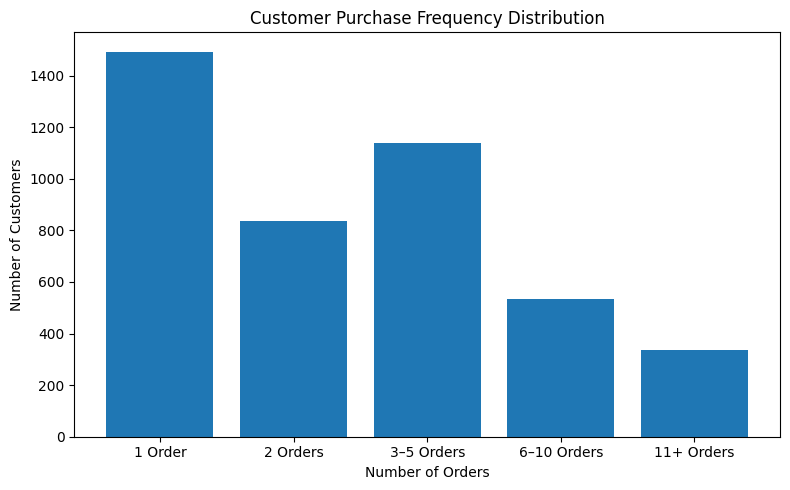

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(frequency_groups["Frequency_Group"].astype(str), frequency_groups["Customer_Count"])

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Defining the Retention Outcome for Machine Learning

In [42]:
# Inspect the monthly transaction coverage
sales_df["InvoiceMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

monthly_activity = (
    sales_df.groupby("InvoiceMonth")
    .agg(
        Transactions=("InvoiceNo", "count"),
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)
monthly_activity

,InvoiceMonth,Transactions,Customers
0,2010-12,40991,885
1,2011-01,34060,741
2,2011-02,26882,758
3,2011-03,35497,974
4,2011-04,28882,856
5,2011-05,35917,1056
6,2011-06,35716,991
7,2011-07,38395,949
8,2011-08,34264,935
9,2011-09,48900,1266


### 6. Defining the Retention Prediction Window

To develop a future-looking retention outcome, customer behavior is
divided into a historical feature period and a subsequent outcome period.
```
          FEATURE PERIOD
          2010-12-01 → 2011-08-31

          OUTCOME PERIOD
          2011-09-01 → 2011-11-30
```
The feature period ends on 31 August 2011. Customer behavior during
September through November 2011 is then used to determine whether the
customer returned during the future observation window.

December 2011 is excluded from the outcome period because the dataset
ends on 9 December and therefore does not represent a complete month.

In [43]:
# Define feature and outcome periods
feature_end = pd.Timestamp("2011-08-31 23:59:59")
outcome_start = pd.Timestamp("2011-09-01 00:00:00")
outcome_end = pd.Timestamp("2011-11-30 23:59:59")

print("Feature period ends:", feature_end)
print("Outcome period:", outcome_start, "to", outcome_end)

Feature period ends: 2011-08-31 23:59:59
Outcome period: 2011-09-01 00:00:00 to 2011-11-30 23:59:59


### 7. Historical Customer Features Using SQL

Customer behavior before the prediction cutoff is used to construct
the features for the retention model.
Only transactions occurring on or before 31 August 2011 are included.


In [47]:
historical_features_sql = con.execute("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS Historical_Orders,
        MIN(InvoiceDate) AS First_Purchase_Date,
        MAX(InvoiceDate) AS Last_Purchase_Date
    FROM customer_orders
    WHERE InvoiceDate <= '2011-08-31 23:59:59'
    GROUP BY CustomerID
    ORDER BY CustomerID
""").df()

historical_features_sql.head()

,CustomerID,Historical_Orders,First_Purchase_Date,Last_Purchase_Date
0,12346.0,1,2011-01-18 10:01:00,2011-01-18 10:01:00
1,12347.0,5,2010-12-07 14:57:00,2011-08-02 08:48:00
2,12348.0,3,2010-12-16 19:09:00,2011-04-05 10:47:00
3,12350.0,1,2011-02-02 16:01:00,2011-02-02 16:01:00
4,12352.0,5,2011-02-16 12:33:00,2011-03-22 16:08:00


In [48]:
print("Historical customer feature table:", historical_features_sql.shape)
historical_features_sql.describe(include="all")

Historical customer feature table: (3317, 4)


,CustomerID,Historical_Orders,First_Purchase_Date,Last_Purchase_Date
count,3317.000000,3317.000000,3317,3317
mean,15284.195659,3.440760,2011-03-08 19:06:06.891769856,2011-05-31 09:35:22.303286272
min,12346.000000,1.000000,2010-12-01 08:26:00,2010-12-01 09:53:00
25%,13799.000000,1.000000,2010-12-17 14:15:00,2011-04-07 19:16:00
50%,15245.000000,2.000000,2011-02-28 09:26:00,2011-06-20 10:13:00
75%,16770.000000,4.000000,2011-05-06 13:01:00,2011-08-04 15:23:00
max,18287.000000,127.000000,2011-08-31 17:12:00,2011-08-31 17:16:00
std,1724.184899,5.586463,NaN,NaN


### 8. Future Retention Outcome

A customer is considered retained if they place at least one order
during the September–November 2011 outcome period.

Customers with no order during this period are classified as
not retained and will form the churn-risk class for the subsequent
ML analysis.

In [54]:
future_outcome_sql = con.execute("""
    SELECT
        CustomerID,
        COUNT(DISTINCT InvoiceNo) AS Future_Orders
    FROM customer_orders
    WHERE InvoiceDate >= '2011-09-01 00:00:00'
      AND InvoiceDate <= '2011-11-30 23:59:59'
    GROUP BY CustomerID
    ORDER BY CustomerID
""").df()

print("Future customer outcome table:", future_outcome_sql.shape)
future_outcome_sql.head()

Future customer outcome table: (2851, 2)


,CustomerID,Future_Orders
0,12347.0,1
1,12348.0,1
2,12349.0,1
3,12352.0,3
4,12356.0,1


### 9. Creating the Retention Target

The historical customer features are combined with future purchasing
behavior.

Customers who place at least one order during the outcome period are
classified as retained. Customers with no future order are classified
as not retained.

- 1 -> retained
- 0 -> non-retained/churn-risk

In [51]:
retention_target_sql = con.execute("""
    SELECT
        h.CustomerID,
        h.Historical_Orders,
        h.First_Purchase_Date,
        h.Last_Purchase_Date,
        
        COALESCE(f.Future_Orders, 0) AS Future_Orders,  # 0 is for the non-retained/one-time purchase customers
        CASE
            WHEN f.CustomerID IS NOT NULL THEN 1
            ELSE 0
        END AS Retained
    FROM historical_features_sql h
    LEFT JOIN future_outcome_sql f
        ON h.CustomerID = f.CustomerID
    ORDER BY h.CustomerID
""").df()

retention_target_sql.head()

,CustomerID,Historical_Orders,First_Purchase_Date,Last_Purchase_Date,Future_Orders,Retained
0,12346.0,1,2011-01-18 10:01:00,2011-01-18 10:01:00,0,0
1,12347.0,5,2010-12-07 14:57:00,2011-08-02 08:48:00,1,1
2,12348.0,3,2010-12-16 19:09:00,2011-04-05 10:47:00,1,1
3,12350.0,1,2011-02-02 16:01:00,2011-02-02 16:01:00,0,0
4,12352.0,5,2011-02-16 12:33:00,2011-03-22 16:08:00,3,1


### 10. Retention Target Distribution

This determines the proportion of customers who returned during the
future observation period versus those who did not.
```
Retained = 1 → customer made at least one purchase during Sep–Nov 2011.
Retained = 0 → customer made no purchase during Sep–Nov 2011.
```

In [55]:
retention_target_sql["Retained"].value_counts(normalize=True).mul(100).round(2)

Retained
1    56.41
0    43.59
Name: proportion, dtype: float64

### 11. Historical Customer Behavioral Features

- Historical recency measures how recently the customer purchased before
the cutof. 
- Customer tenure measures the length of the observed
customer relationship lifespan.

In [56]:
historical_features_sql = con.execute("""
    SELECT
        CustomerID,
        Historical_Orders,
        First_Purchase_Date,
        Last_Purchase_Date,

        DATEDIFF(
            'day',
            Last_Purchase_Date,
            '2011-08-31 23:59:59'
        ) AS Historical_Recency,

        DATEDIFF(
            'day',
            First_Purchase_Date,
            Last_Purchase_Date
        ) AS Customer_Tenure

    FROM historical_features_sql
    ORDER BY CustomerID
""").df()

historical_features_sql.head()

,CustomerID,Historical_Orders,First_Purchase_Date,Last_Purchase_Date,Historical_Recency,Customer_Tenure
0,12346.0,1,2011-01-18 10:01:00,2011-01-18 10:01:00,225,0
1,12347.0,5,2010-12-07 14:57:00,2011-08-02 08:48:00,29,238
2,12348.0,3,2010-12-16 19:09:00,2011-04-05 10:47:00,148,110
3,12350.0,1,2011-02-02 16:01:00,2011-02-02 16:01:00,210,0
4,12352.0,5,2011-02-16 12:33:00,2011-03-22 16:08:00,162,34


### 12. Final Retention Modeling Dataset

Historical customer behavior is combined with the future retention
outcome to create the dataset used for subsequent predictive modeling.

All predictor variables are calculated before the cutoff date, while
the retention target is determined from the subsequent outcome period.

In [57]:
retention_model_sql = con.execute("""
    SELECT
        h.CustomerID,
        h.Historical_Orders,
        h.Historical_Recency,
        h.Customer_Tenure,
        r.Future_Orders,
        r.Retained

    FROM historical_features_sql h
    INNER JOIN retention_target_sql r
        ON h.CustomerID = r.CustomerID

    ORDER BY h.CustomerID
""").df()

retention_model_sql.head()

,CustomerID,Historical_Orders,Historical_Recency,Customer_Tenure,Future_Orders,Retained
0,12346.0,1,225,0,0,0
1,12347.0,5,29,238,1,1
2,12348.0,3,148,110,1,1
3,12350.0,1,210,0,0,0
4,12352.0,5,162,34,3,1


### 13. Historical Predictor Validation

The historical predictor variables are checked for missing values,
data types, and basic distributions before they are used for
predictive modeling.

In [58]:
retention_model_sql[
    [
        "Historical_Orders",
        "Historical_Recency",
        "Customer_Tenure"
    ]
].describe()

,Historical_Orders,Historical_Recency,Customer_Tenure
count,3317.000000,3317.000000,3317.000000
mean,3.440760,92.142900,83.603256
std,5.586463,76.687522,91.970120
min,1.000000,0.000000,0.000000
25%,1.000000,27.000000,0.000000
50%,2.000000,72.000000,49.000000
75%,4.000000,146.000000,163.000000
max,127.000000,273.000000,272.000000


In [60]:
# Save Retention Modeling Dataset
retention_model_file = PROCESSED_DIR / "retention_modeling_data.csv"

retention_model_sql.to_csv(retention_model_file, index=False)

print(f"Retention modeling dataset saved to: {retention_model_file}")
print(f"Shape: {retention_model_sql.shape}")

Retention modeling dataset saved to: C:\Users\tanya\Retail_Sales_Customer_Analytics\data\processed\retention_modeling_data.csv
Shape: (3317, 6)


## Churn Definition

For this project, churn-risk is defined as non-retention during the
future observation period.

A customer is classified as:

- **Retained (1):** at least one purchase during September–November 2011.
- **Churn-risk / Non-retained (0):** no purchase during September–November 2011.

The historical feature period ends on 31 August 2011.